In [10]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

        

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sohaibdevv/ai-and-data-science-job-market-2025-2026/AI_Job_Market_Trends_2026.csv


   job_id                  job_title company_size company_industry    country  \
0       1                AI Engineer      Startup           Retail     Canada   
1       2  Machine Learning Engineer          MNC       Technology  Australia   
2       3  Machine Learning Engineer          MNC       Technology    Germany   
3       4           Business Analyst      Startup       Healthcare    Germany   
4       5             Data Scientist          MNC       Healthcare    Germany   

  remote_type experience_level  years_experience education_level  \
0      Remote           Senior                 2          Master   
1      Hybrid              Mid                 0        Bachelor   
2      Onsite              Mid                14          Master   
3      Remote              Mid                 9          Master   
4      Hybrid              Mid                 5          Master   

   skills_python  skills_sql  skills_ml  skills_deep_learning  skills_cloud  \
0              0         

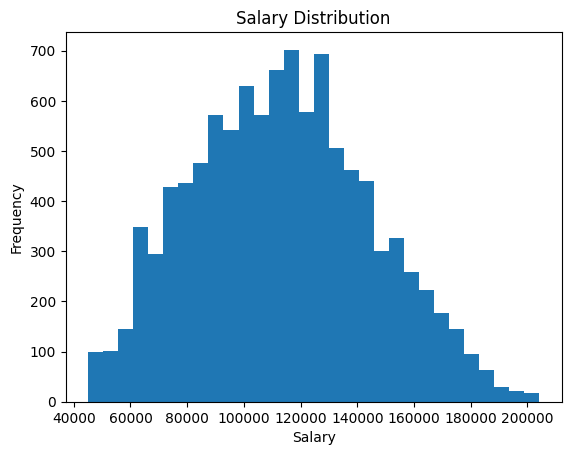

<Figure size 640x480 with 0 Axes>

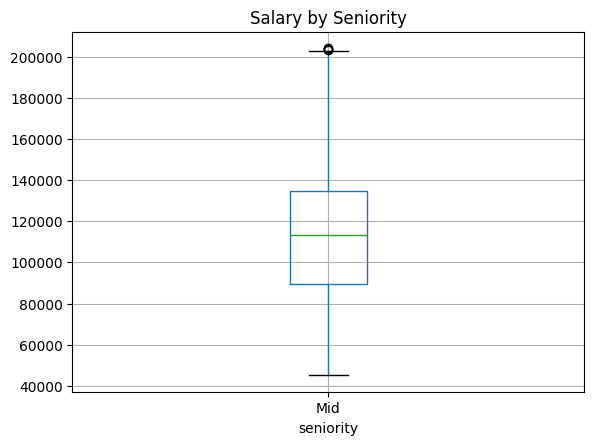


Linear Regression Performance:
MAE: 2448.5489013807405
RMSE: 2846.9435465946926
R2: 0.991859873412664

Random Forest Performance:
MAE: 2595.826099565007
RMSE: 3074.0433989591133
R2: 0.9905094050846243


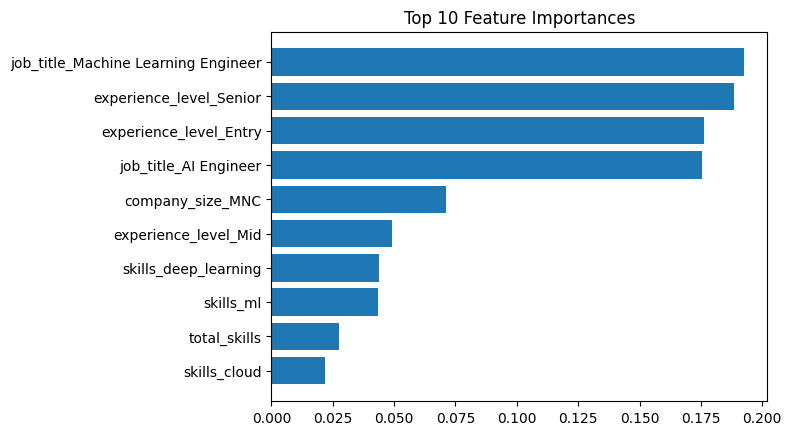

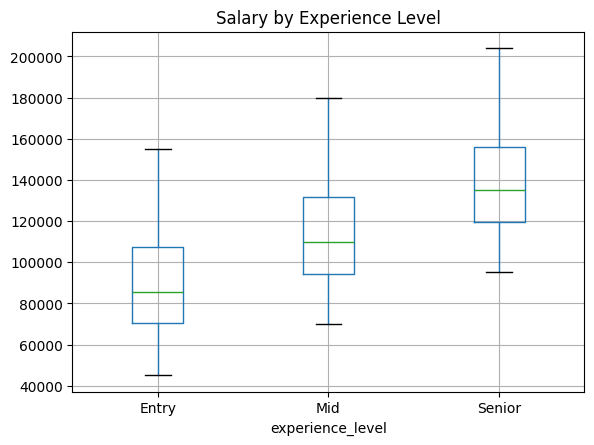

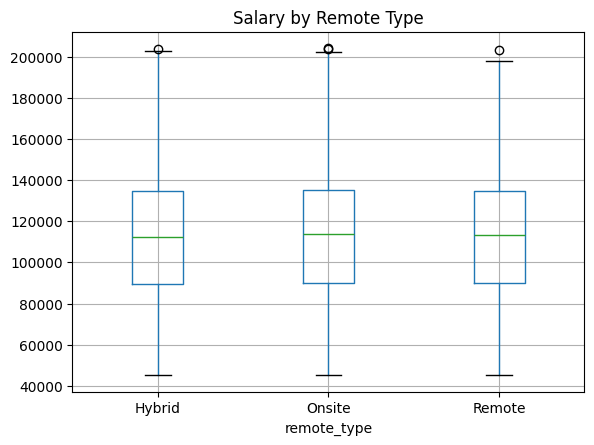

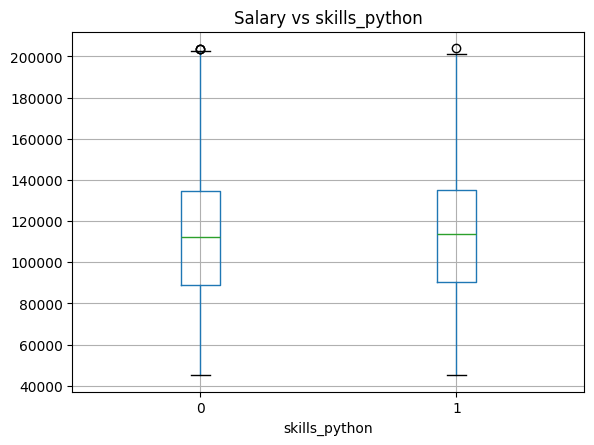

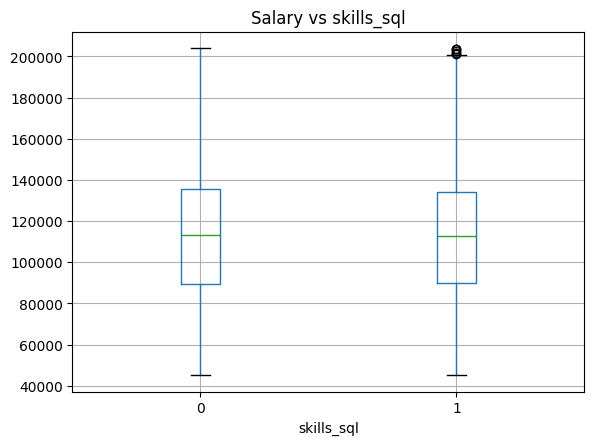

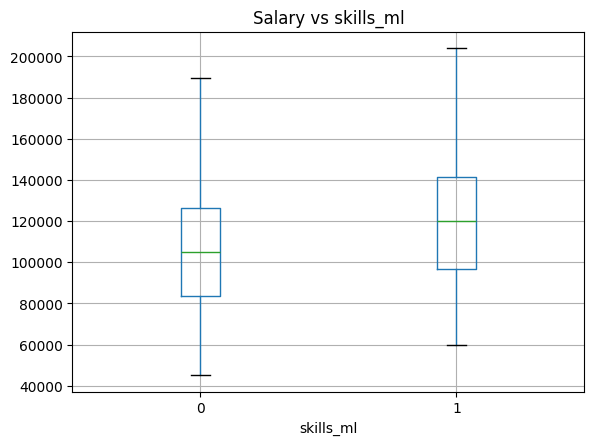

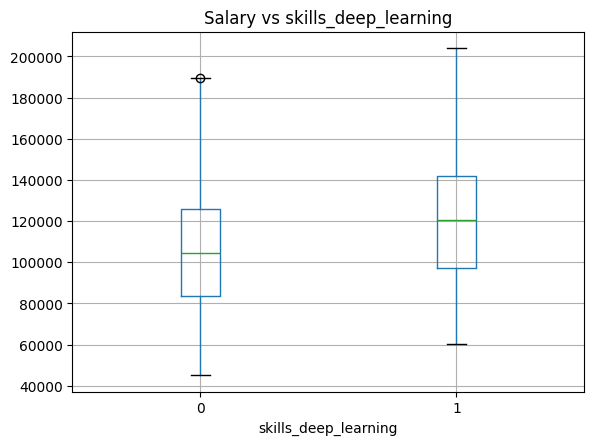

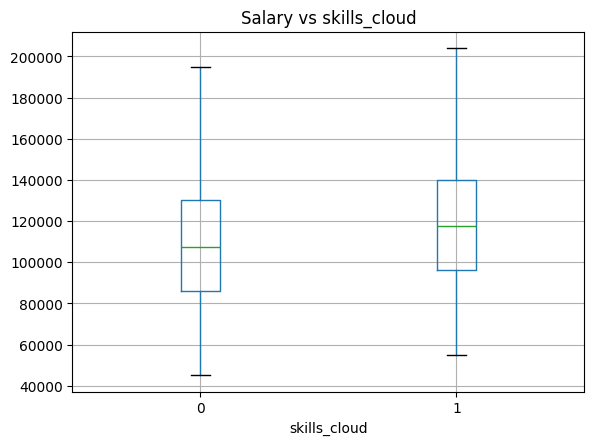

In [11]:
# AI Job Salary Prediction & Market Insights

# =========================
# 1. Problem Statement
# =========================
"""
This project analyzes AI job market data to identify key factors influencing salaries
and builds a machine learning model to predict compensation based on job characteristics.

Goals:
- Understand what drives AI salaries
- Build a predictive model
- Provide actionable insights
"""

# =========================
# 2. Imports
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# 3. Load Data
# =========================
df = pd.read_csv("/kaggle/input/datasets/sohaibdevv/ai-and-data-science-job-market-2025-2026/AI_Job_Market_Trends_2026.csv")  

print(df.head())
print(df.info())

# =========================
# 4. Data Cleaning
# =========================

# Handle missing values
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna('Unknown')

for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

df = df.drop(columns=['job_id'])

# =========================
# 5. Feature Engineering
# =========================

# Example: seniority from title
def get_seniority(title):
    title = title.lower()
    if 'senior' in title:
        return 'Senior'
    elif 'junior' in title:
        return 'Junior'
    else:
        return 'Mid'

if 'job_title' in df.columns:
    df['seniority'] = df['job_title'].apply(get_seniority)

# Example: total skills (adjust based on dataset)
skill_cols = [col for col in df.columns if 'skill' in col.lower()]
if skill_cols:
    df['total_skills'] = df[skill_cols].sum(axis=1)

skill_cols = ['skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud']
df['total_skills'] = df[skill_cols].sum(axis=1)

# =========================
# 6. Exploratory Data Analysis
# =========================

# Salary distribution
if 'salary' in df.columns:
    plt.figure()
    plt.hist(df['salary'], bins=30)
    plt.title("Salary Distribution")
    plt.xlabel("Salary")
    plt.ylabel("Frequency")
    plt.show()

# Salary by seniority
if 'seniority' in df.columns:
    plt.figure()
    df.boxplot(column='salary', by='seniority')
    plt.title("Salary by Seniority")
    plt.suptitle("")
    plt.show()

# =========================
# 7. Modeling
# =========================

# Define target
TARGET = 'salary'

# Drop unused columns
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Column types
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=[np.number]).columns

# Preprocessing
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# Models
lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train models
lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# Predictions
lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

# =========================
# 8. Evaluation
# =========================

def evaluate(name, y_true, y_pred):
    print(f"\n{name} Performance:")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2:", r2_score(y_true, y_pred))


evaluate("Linear Regression", y_test, lr_preds)
evaluate("Random Forest", y_test, rf_preds)

# =========================
# 9. Feature Importance (Random Forest)
# =========================

# Extract feature names after encoding
rf = rf_model.named_steps['model']
ohe = rf_model.named_steps['preprocessor'].named_transformers_['cat']

encoded_cat_features = ohe.get_feature_names_out(categorical_cols)
all_features = np.concatenate([numerical_cols, encoded_cat_features])

importances = rf.feature_importances_
feat_imp = pd.DataFrame({'feature': all_features, 'importance': importances})
feat_imp = feat_imp.sort_values(by='importance', ascending=False).head(10)

plt.figure()
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.title("Top 10 Feature Importances")
plt.gca().invert_yaxis()
plt.show()

df.boxplot(column='salary', by='experience_level')
plt.title("Salary by Experience Level")
plt.suptitle("")
plt.show()

df.boxplot(column='salary', by='remote_type')
plt.title("Salary by Remote Type")
plt.suptitle("")
plt.show()

for skill in skill_cols:
    df.boxplot(column='salary', by=skill)
    plt.title(f"Salary vs {skill}")
    plt.suptitle("")
    plt.show()

importances = rf_model.named_steps['model'].feature_importances_

# =========================
# 10. Key Insights
# =========================

More years of experience strongly increases salary
Having multiple technical skills (ML + Cloud + Python) significantly boosts pay
Remote and hybrid roles offer competitive salaries vs onsite
Senior/expert roles dominate the highest salary range
Machine Learning and Cloud skills are among the most valuable


# =========================
# 11. Conclusion
# =========================

This project demonstrates how machine learning can be used to analyze job market trends
and predict salaries. The findings provide valuable insights for both job seekers and employers.

